<a href="https://colab.research.google.com/github/BhaveshJoshi934/RTR2020/blob/master/MultiLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7,5)
NAVY = "#004BA0"
GOLD = "#D1AB3E"

In [4]:
df = pd.read_csv("IPLPlayerStat.csv")
#df.head()
if "Unnamed: 0" in df.columns:
  df = df.drop(columns=["Unnamed: 0"])
print("Shape:", df.shape)
df.head()

Shape: (605, 16)


,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [5]:
df["balls_faced"].describe()

,balls_faced
count,605.000000
mean,373.477686
std,764.432561
min,1.000000
25%,18.000000
50%,73.000000
75%,285.000000
max,5266.000000


In [6]:
print(df.isna().sum())

player                 0
runs                   0
boundaries             0
balls_faced            0
wickets                0
balls_bowled           0
runs_conceded          0
matches                0
batting_avg            0
batting_strike_rate    0
boundaries_percent     0
bowling_economy        0
bowling_avg            0
bowling_strike_rate    0
catches                0
stumpings              0
dtype: int64


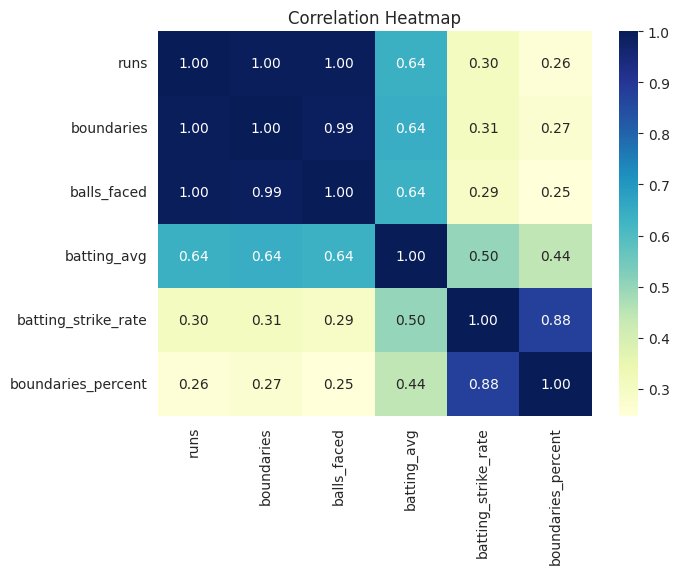

In [7]:
cols = ["runs", "boundaries", "balls_faced", "batting_avg", "batting_strike_rate", "boundaries_percent"]

plt.figure(figsize=(7,5))
sns.heatmap(df[cols].corr(),annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()

In [8]:
X = df[["balls_faced"]]
y = df["runs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", round(model.intercept_, 2))
print("Slope:", round(model.coef_[0], 4))
print(f"\nMeaning: every extra balls faced adds ~{model.coef_[0]:.2f} runs on average.")

Intercept: -15.33
Slope: 1.2844

Meaning: every extra balls faced adds ~1.28 runs on average.


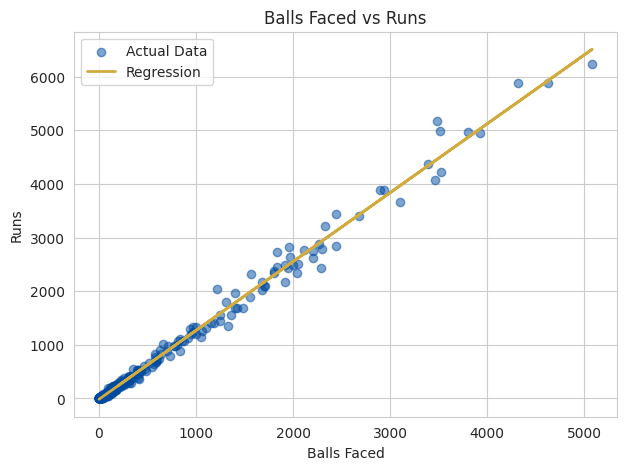

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, color = NAVY, alpha = 0.5, label = "Actual Data")
plt.plot(X_train, model.predict(X_train), color = GOLD, linewidth = 2, label = "Regression")
#plt.plot(X_train, y_train, color = GOLD, linewidth = 2, label = "Regression")
plt.xlabel("Balls Faced")
plt.ylabel("Runs")
plt.title("Balls Faced vs Runs")
plt.legend()
plt.show()

In [10]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "balls_faced": X_test["balls_faced"].values,
    "actual_runs": y_test.values,
    "predicted_runs": np.round(y_pred, 1)
})
comparison.head()

,balls_faced,actual_runs,predicted_runs
0,434,522,542.1
1,27,40,19.3
2,57,76,57.9
3,31,21,24.5
4,552,663,693.6


In [11]:
new_players = pd.DataFrame({"balls_faced":[100,300,600]})
new_preds = model.predict(new_players)

for balls, runs in zip(new_players["balls_faced"], new_preds):
  print(f"Balls Faced = {balls} -> Predicted Runs = {runs:.0f}")

Balls Faced = 100 -> Predicted Runs = 113
Balls Faced = 300 -> Predicted Runs = 370
Balls Faced = 600 -> Predicted Runs = 755


In [15]:
#features = ["stumping", "matches", "batting_avg", "batting_strike_rate", "catches"]
features = ['balls_faced', 'boundaries', 'balls_bowled', 'stumpings', 'batting_strike_rate']
X_multi = df[features]
y_multi = df["runs"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

print("Intercept:", round(multi_model.intercept_, 2))
for f, c in zip(features, multi_model.coef_):
  print(f"{f}: {c:.4f}")

Intercept: -18.07
balls_faced: 0.6805
boundaries: 3.5326
balls_bowled: 0.0045
stumpings: 2.2614
batting_strike_rate: 0.1359


In [16]:
y_pred_multi = multi_model.predict(X_test_m)
pd.DataFrame({"actual":y_test_m.values[:10], "predicted": np.round(y_pred_multi[:10],1)})

,actual,predicted
0,522,513.3
1,40,41.6
2,76,75.0
3,21,19.3
4,663,649.4
5,985,989.7
6,34,36.4
7,12,9.8
8,20,17.0
9,920,873.4


In [17]:
def adjusted_r2(r2, n, p):
  #n = number of rows, p = number of features used
  return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def evaluate(name, y_true, y_pred, n_features):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  adj_r2 = adjusted_r2(r2, len(y_true), n_features)

  print(f"---------{name}----------")
  print(f"MAE: {mae:.2f}")
  print(f"MSE: {mse:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print(f"R2: {r2:.4f}")
  print(f"Adjusted R2: {adj_r2:.4f}\n")
  return {"model":name, "mae":mae, "mse":mse, "rmse":rmse, "r2":r2, "adj_r2":adj_r2}

results = []
results.append(evaluate("Linear Regression", y_test, y_pred, 1))
results.append(evaluate("Multiple Linear Regression", y_test_m, y_pred_multi, len(features)))

---------Linear Regression----------
MAE: 33.81
MSE: 3246.97
RMSE: 56.98
R2: 0.9968
Adjusted R2: 0.9967

---------Multiple Linear Regression----------
MAE: 19.18
MSE: 1619.34
RMSE: 40.24
R2: 0.9984
Adjusted R2: 0.9983

